# 1. Import libaries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load segmentation Results

In [30]:
classic_df = pd.read_parquet("data/delivery/rfm_with_classic_segments.parquet")
kmeans_df = pd.read_parquet("data/delivery/rfm_with_kmeans_clusters.parquet")
hier_df = pd.read_parquet("data/delivery/rfm_with_hier_clusters.parquet")

In [31]:
# Rename classic segment
classic_df.rename(columns={'rfm_classic_segment':'classic_cluster_name'}, inplace=True)

In [32]:
# Review tructure
classic_df.head()

,household_key,recency,frequency,monetary,classic_cluster_name
0,1,6,86,4330.16,2. Loyalist
1,3,9,46,2519.75,6. Need Attention
2,5,9,39,757.07,7. About To Sleep
3,6,5,242,5613.98,2. Loyalist
4,7,3,59,3350.77,2. Loyalist


In [ ]:
# Review tructure
kmeans_df.head()

,household_key,recency,frequency,monetary,kmeans_5_cluster_id,kmeans_5_cluster_name,kmeans_6_cluster_id,kmeans_6_cluster_name
0,1,6,86,4330.16,1,2. Loyalist,1,2. Loyalist
1,3,9,46,2519.75,2,4. New Customers,2,4. New Customers
2,5,9,39,757.07,2,4. New Customers,2,4. New Customers
3,6,5,242,5613.98,0,1. Champions,0,1. Champions
4,7,3,59,3350.77,4,3. Potential Loyalist,4,3. Potential Loyalist


In [34]:
# Review tructure
hier_df.head()

,household_key,recency,frequency,monetary,hier_5_cluster_id,hier_6_cluster_id,hier_5_cluster_name,hier_6_cluster_name
0,1,6,86,4330.16,0,0,4. New Customers,4. New Customers
1,3,9,46,2519.75,0,0,4. New Customers,4. New Customers
2,5,9,39,757.07,0,0,4. New Customers,4. New Customers
3,6,5,242,5613.98,1,1,1. Champions,1. Champions
4,7,3,59,3350.77,0,0,4. New Customers,4. New Customers


# 3. Clusters size comparison

In [35]:
sns.set_theme(style="whitegrid")

In [42]:
# Set a fixed color mapping
color_map = {
    '1. Champions': '#1a9850',           # strong green
    '2. Loyalist': '#66bd63',            # green
    '3. Potential Loyalist': '#a6d96a',  # light green
    '4. New Customers': '#d9ef8b',       # yellow-green
    '5. Promising': '#fee08b',           # yellow
    '6. Need Attention': '#fdae61',      # light orange
    '7. About To Sleep': '#f46d43',      # orange
    '8. Can\'t Lose': '#d53e4f',         # strong red
    '9. At Risk': '#9e0142',             # dark red
    '10. Hibernating': '#bdbdbd'         # gray (inactive)
}

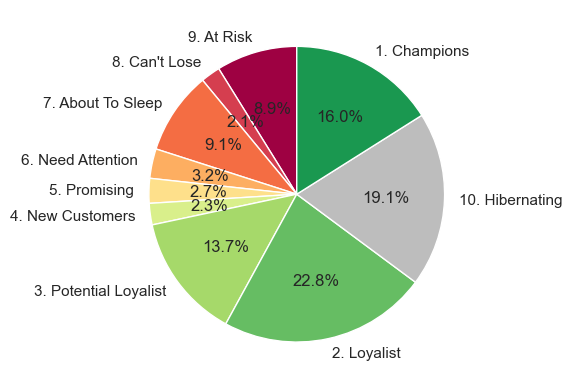

In [51]:
counts = classic_df['classic_cluster_name'].value_counts().sort_index(ascending=False)

plt.pie(
    counts,
    labels=counts.index,
    colors=[color_map[label] for label in counts.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.show()

In [44]:
classic_df['classic_cluster_name'].unique()

<ArrowStringArray>
[          '2. Loyalist',     '6. Need Attention',     '7. About To Sleep',
       '10. Hibernating',            '9. At Risk',          '1. Champions',
 '3. Potential Loyalist',      '4. New Customers',          '5. Promising',
         '8. Can't Lose']
Length: 10, dtype: str

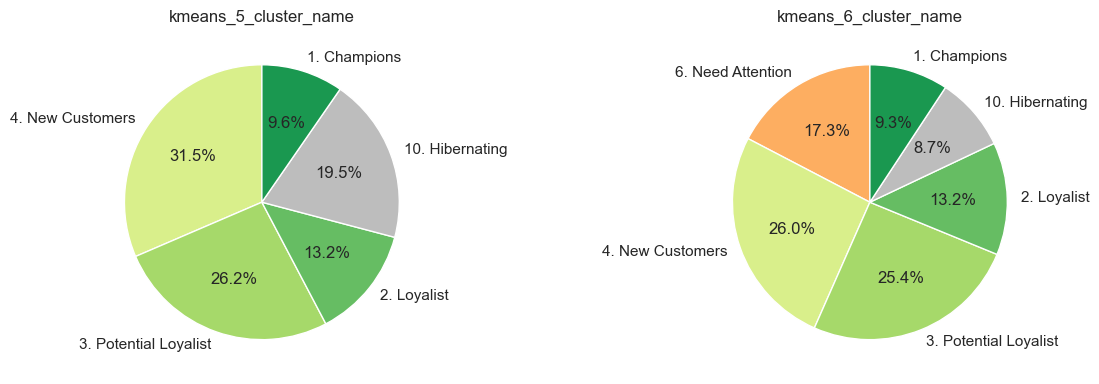

In [50]:
cols = ['kmeans_5_cluster_name', 'kmeans_6_cluster_name']

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, col in zip(axes, cols):
    counts = kmeans_df[col].value_counts().sort_index(ascending=False)
    colors = [color_map[i] for i in counts.index]

    ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)

plt.tight_layout()
plt.show()

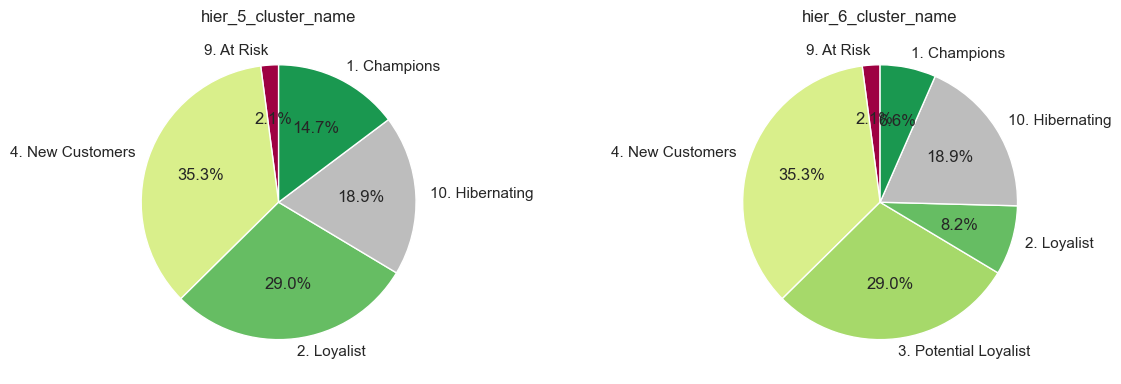

In [52]:
cols = ['hier_5_cluster_name', 'hier_6_cluster_name']

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, col in zip(axes, cols):
    counts = hier_df[col].value_counts().sort_index(ascending=False)
    colors = [color_map[i] for i in counts.index]

    ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [60]:
segments = list(color_map.keys())

segments_df = pd.DataFrame({
    'rfm_classic_segment': segments,
    
    'rfm_classic_segment_distribution': (
        classic_df['classic_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values * 100
    ),
    
    'kmeans_5_cluster_distribution': (
        kmeans_df['kmeans_5_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values * 100
    ),

    'kmeans_6_cluster_distribution': (
        kmeans_df['kmeans_6_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values * 100
    ),
    
    'hier_5_cluster_distribution': (
        hier_df['hier_5_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values *100
    ),

    'hier_6_cluster_distribution': (
        hier_df['hier_6_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values *100
    )
})

segments_df = segments_df.round(1)
segments_df

,rfm_classic_segment,rfm_classic_segment_distribution,kmeans_5_cluster_distribution,kmeans_6_cluster_distribution,hier_5_cluster_distribution,hier_6_cluster_distribution
0,1. Champions,16.0,9.6,9.3,14.7,6.6
1,2. Loyalist,22.8,13.2,13.2,29.0,8.2
2,3. Potential Loyalist,13.7,26.2,25.4,0.0,29.0
3,4. New Customers,2.3,31.5,26.0,35.3,35.3
4,5. Promising,2.7,0.0,0.0,0.0,0.0
5,6. Need Attention,3.2,0.0,17.3,0.0,0.0
6,7. About To Sleep,9.1,0.0,0.0,0.0,0.0
7,8. Can't Lose,2.1,0.0,0.0,0.0,0.0
8,9. At Risk,8.9,0.0,0.0,2.1,2.1
9,10. Hibernating,19.1,19.5,8.7,18.9,18.9


> Increasing the number of clusters from 5 to 6 reveals additional behavioral sub-segments in different dimensions of the RFM space:
- Increase kmeans clusters count from 5 to 6 introduces the "Need Attention" sub group (a segmentation on Recency axis)

- Increase hier clusters count from 5 to 6 introduces the "Potential Loyalist" sub group (a segmentation on Value/Frequency axis)

--> Different clustering algorithms emphasize different behavioral dimensions.

> Hierachical methods introduces minor sub group "At Risk" at just 2% of the total customers --> depend on how significant this group is, this segmentation will become less attractive to the business teams

# 4. Analyze Recency distribution

In [72]:
# Select only needed columns
classic = classic_df[['household_key', 'recency', 'classic_cluster_name']].copy()
classic['method'] = 'classic'
classic.rename(columns={'classic_cluster_name': 'cluster'}, inplace=True)

kmeans5 = kmeans_df[['household_key', 'recency', 'kmeans_5_cluster_name']].copy()
kmeans5['method'] = 'kmeans_5'
kmeans5.rename(columns={'kmeans_5_cluster_name': 'cluster'}, inplace=True)

kmeans6 = kmeans_df[['household_key', 'recency', 'kmeans_6_cluster_name']].copy()
kmeans6['method'] = 'kmeans_6'
kmeans6.rename(columns={'kmeans_6_cluster_name': 'cluster'}, inplace=True)

hier5 = hier_df[['household_key', 'recency', 'hier_5_cluster_name']].copy()
hier5['method'] = 'hier_5'
hier5.rename(columns={'hier_5_cluster_name': 'cluster'}, inplace=True)

hier6 = hier_df[['household_key', 'recency', 'hier_6_cluster_name']].copy()
hier6['method'] = 'hier_6'
hier6.rename(columns={'hier_6_cluster_name': 'cluster'}, inplace=True)

# Combine all
recency_df = pd.concat([classic, kmeans5, kmeans6, hier5, hier6], ignore_index=True)

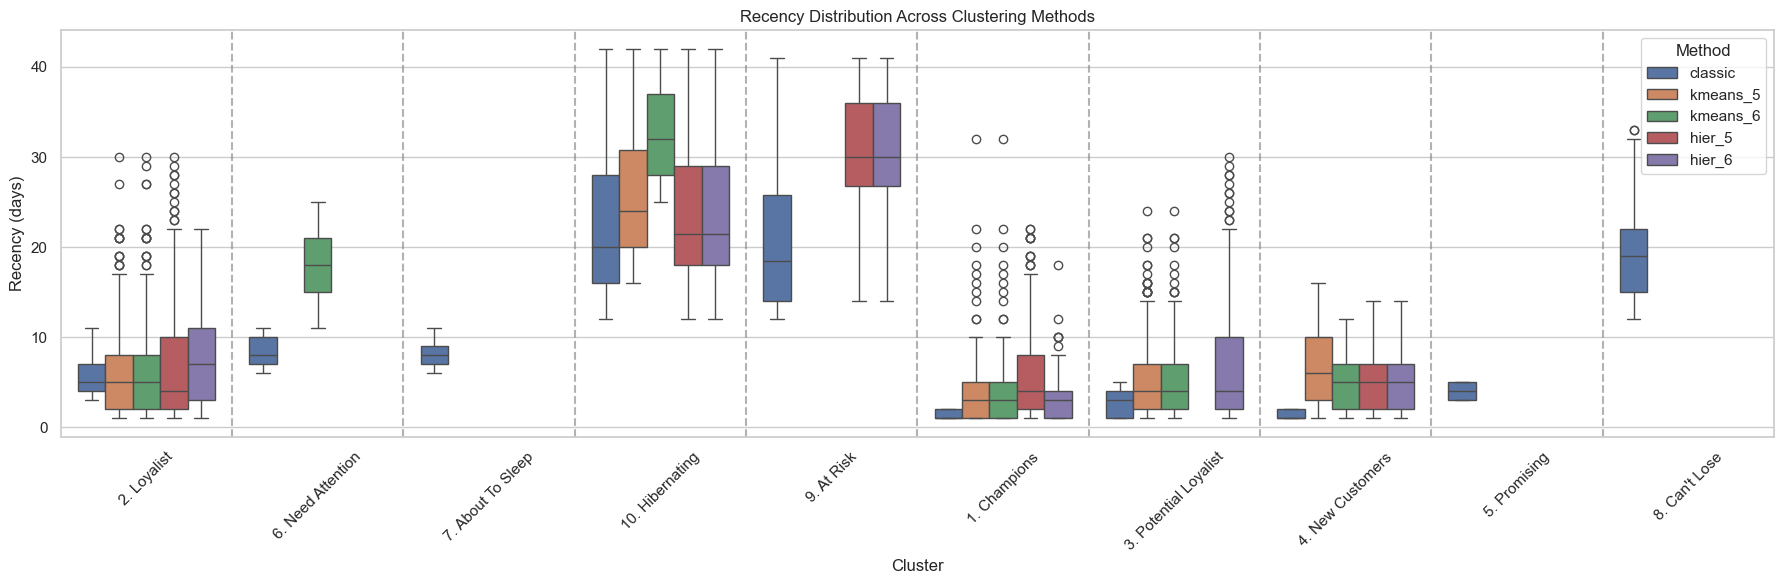

In [73]:
plt.figure(figsize=(18,6))

ax = sns.boxplot(
    data=recency_df,
    x='cluster',
    y='recency',
    hue='method'
)

# Add vertical dividers between clusters
clusters = recency_df['cluster'].unique()
for i in range(len(clusters) - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.title("Recency Distribution Across Clustering Methods")
plt.xlabel("Cluster")
plt.ylabel("Recency (days)")
plt.legend(title="Method")

plt.tight_layout()
plt.show()


> The clusters Loyalist, Champions, Potential Loyalist, and New Customers show similar recency distributions across methods. This indicates that these customer groups are stable segments, meaning that regardless of the segmentation technique (classic RFM, K-Means, or hierarchical clustering), customers with similar purchase recency are grouped consistently.

--> Recency strongly drives these behavioral segments, so both rule-based and unsupervised clustering detect them reliably.

> KMeans = 6 produces a tighter distribution for the "Hibernating" group 

--> Increasing the number of clusters allowed K-Means to isolate a more homogeneous inactive-customer segment.

# 5. Analyze Frequency distribution

In [74]:
# Select only needed columns
classic = classic_df[['household_key', 'frequency', 'classic_cluster_name']].copy()
classic['method'] = 'classic'
classic.rename(columns={'classic_cluster_name': 'cluster'}, inplace=True)

kmeans5 = kmeans_df[['household_key', 'frequency', 'kmeans_5_cluster_name']].copy()
kmeans5['method'] = 'kmeans_5'
kmeans5.rename(columns={'kmeans_5_cluster_name': 'cluster'}, inplace=True)

kmeans6 = kmeans_df[['household_key', 'frequency', 'kmeans_6_cluster_name']].copy()
kmeans6['method'] = 'kmeans_6'
kmeans6.rename(columns={'kmeans_6_cluster_name': 'cluster'}, inplace=True)

hier5 = hier_df[['household_key', 'frequency', 'hier_5_cluster_name']].copy()
hier5['method'] = 'hier_5'
hier5.rename(columns={'hier_5_cluster_name': 'cluster'}, inplace=True)

hier6 = hier_df[['household_key', 'frequency', 'hier_6_cluster_name']].copy()
hier6['method'] = 'hier_6'
hier6.rename(columns={'hier_6_cluster_name': 'cluster'}, inplace=True)

# Combine all
frequency_df = pd.concat([classic, kmeans5, kmeans6, hier5, hier6], ignore_index=True)

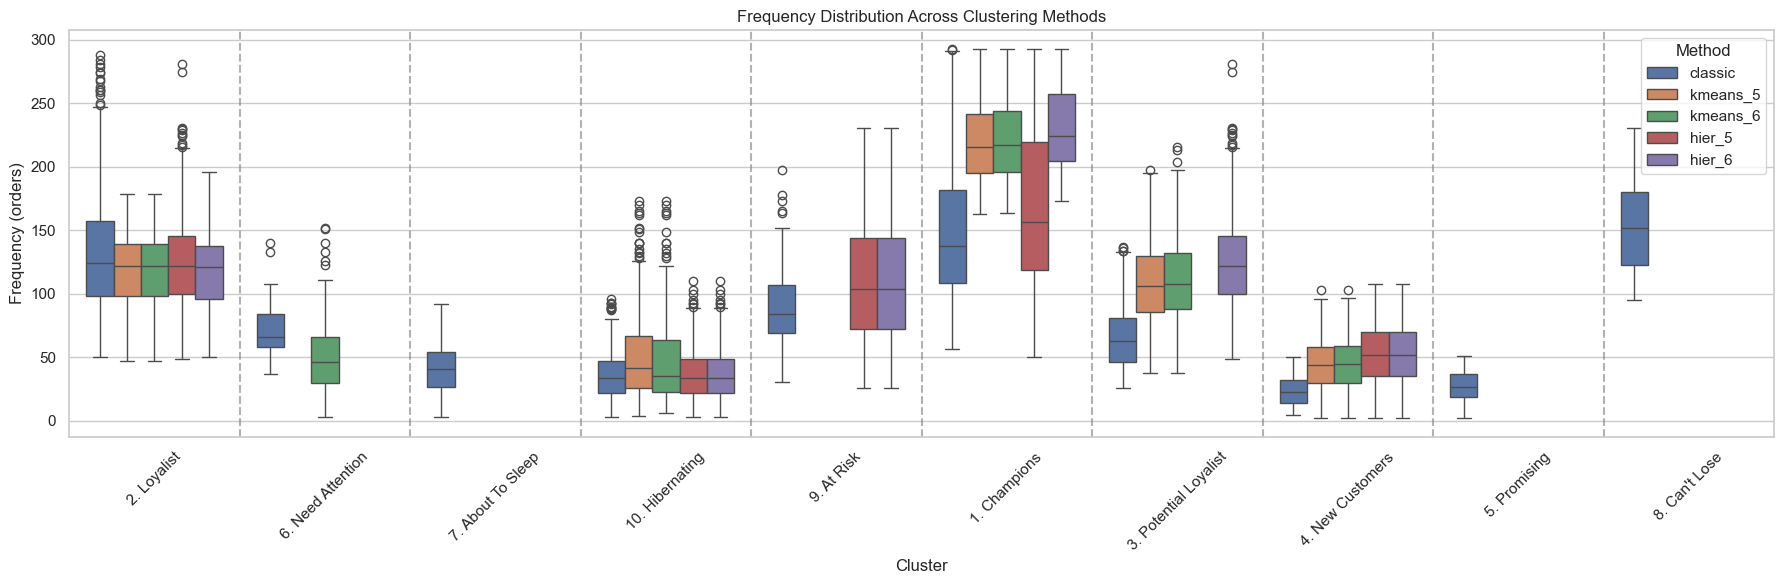

In [75]:
plt.figure(figsize=(18,6))

ax = sns.boxplot(
    data=frequency_df,
    x='cluster',
    y='frequency',
    hue='method'
)

# Add vertical dividers between clusters
clusters = frequency_df['cluster'].unique()
for i in range(len(clusters) - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.title("Frequency Distribution Across Clustering Methods")
plt.xlabel("Cluster")
plt.ylabel("Frequency (orders)")
plt.legend(title="Method")

plt.tight_layout()
plt.show()

> The clusters Loyalist, New Customers, and Hibernating show similar frequency distributions across segmentation methods.

--> Customers in these groups tend to have relatively comparable purchase counts, allowing different segmentation approaches to identify these segments consistently.

> The Champions and Loyalist segments produced by Classic RFM and Hierarchical (k=6) show a broader frequency distribution.

--> These methods allow greater variability in purchase frequency within the same segment. Rather than indicating that Frequency is not an important feature, the broader spread likely reflects that these segmentation approaches rely on combined RFM characteristics and may not strictly minimize within-cluster variance for Frequency, resulting in more heterogeneous clusters.